In [43]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [44]:
def f(x):
  return 3*x**2 - 4*x + 5

In [45]:
f(3.0)

20.0

[-5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25
 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
  4.    4.25  4.5   4.75]
[100.      91.6875  83.75    76.1875  69.      62.1875  55.75    49.6875
  44.      38.6875  33.75    29.1875  25.      21.1875  17.75    14.6875
  12.       9.6875   7.75     6.1875   5.       4.1875   3.75     3.6875
   4.       4.6875   5.75     7.1875   9.      11.1875  13.75    16.6875
  20.      23.6875  27.75    32.1875  37.      42.1875  47.75    53.6875]


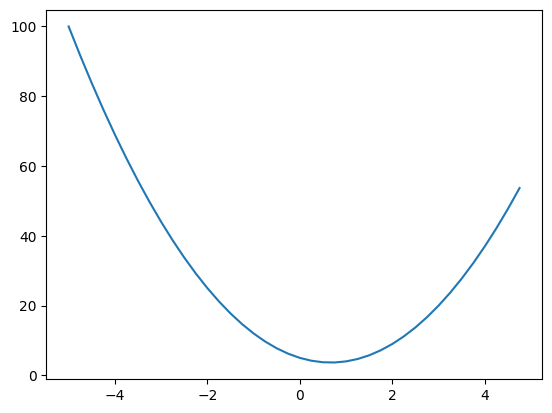

In [46]:
xs = np.arange(-5, 5, 0.25)
print(xs)
ys = f(xs)
print(ys)
plt.plot(xs, ys)

In [47]:
x = -3.0
h = 0.00001
(f(x + h) - f(x))/h

-21.999970000052823

In [48]:
h = 0.00001

a = 2.0
b = -3.0
c = 10.0
d1 = a*b + c

a += h
d2 = a*b + c

print(d1)
print(d2)
print((d2 - d1)/h)


4.0
3.9999699999999994
-3.000000000064062


In [49]:
# Backpropagation for gradients

class Value:
  # These all are constructors
  # Empty tuple, empty set
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None  # Function
    self._prev = set(_children)  # Maintaining here
    self._op = _op  # Maintaining here
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other  = other if isinstance(other, Value) else Value(other)  # For a + 1
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad  # Using += to accumulate grads if vars is used
      other.grad += 1.0 * out.grad  # 1+ times instead of overwriting it with =

    out._backward = _backward
    return out

  def __radd__(self, other):  # For other + self
    return self + other

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad

    out._backward = _backward
    return out

  def __rmul__(self, other):
    return self * other

  def __neg__(self):
    return self * -1

  def __sub__(self, other):
    return self + (-other)

  def __pow__(self, other):
    assert isinstance(other, (int, float))  # Only supports int/float powers
    out = Value(self.data**other, (self, ), f'**{other}')

    def _backward():
      self.grad += other * self.data**(other - 1) * out.grad

    out._backward = _backward
    return out

  def __truediv__(self, other):
    return self * other**-1

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self,), 'tanh')

    def _backward():
      self.grad += (1- t**2) * out.grad

    out._backward = _backward
    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad

    out._backward = _backward

    return out

  def backward(self):
    topo = []  # Topological sort
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)

    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

a = Value(2.0, label='a')
b = Value(-3.0,label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'  # a.__mul__(b).__add__(c)
print(d)
print(d._prev)
print(d._op)
print(L)
print(a + 1)
print(b * 2)
print(1 + a)
print(2 * b)

Value(data=4.0)
{Value(data=-6.0), Value(data=10.0)}
+
Value(data=-8.0)
Value(data=3.0)
Value(data=-6.0)
Value(data=3.0)
Value(data=-6.0)


In [50]:
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()

  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      dot.node(name = uid + n._op, label = n._op)
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

# Forward propagation


In [51]:
L.grad = 1.0  # Manual backpropagation
d.grad = -2.0  # dL/dd = f
f.grad = 4.0  # dL/df = d
# '+' is just a distributor of grads in backprop
c.grad = -2.0  # dL/dc = dd/dc * dL/dd = 1*f
e.grad = -2.0  # dL/de = dd/de * dL/dd = 1*f
b.grad = -4.0 # dL/db = de/db * dd/de * dL/dd = a*1*f
a.grad = 6.0 # dL/da = de/da * dd/de * dL/dd = b*1*f

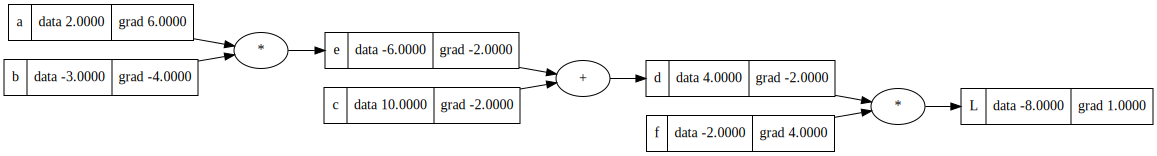

In [52]:
draw_dot(L)

In [53]:
# Verification that grads are working

h = 0.01
# Leaf nodes (which we can control)
a.data += h * a.grad
b.data += h * b.grad
c.data += h * c.grad
f.data += h * f.grad

e = a * b
d = e + c
L = d * f
L.data

-7.286496

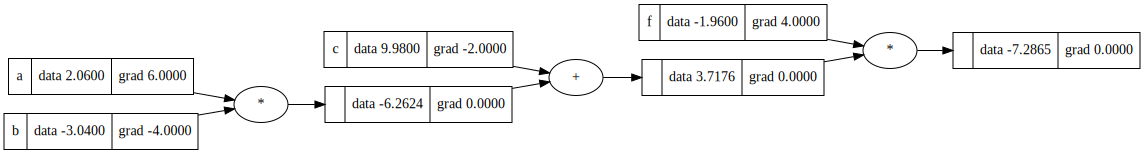

In [54]:
draw_dot(L)

In [55]:
def verify_grad():

  h = 0.001

  a = Value(2.0, label='a')
  b = Value(-3.0,label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d*f; L.label = 'L'
  L1 = L.data

  a = Value(2.0, label='a')
  # a.data += h
  b = Value(-3.0,label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d*f; L.label = 'L'
  L2 = L.data + h

  print(L1)
  print(L2)
  print((L2 - L1)/h)

verify_grad()

-8.0
-7.999
1.000000000000334


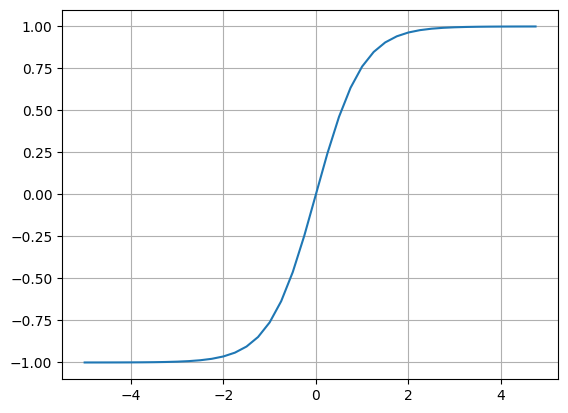

In [56]:
# Sigmoid/tanh is an activation or squeezing function
plt.plot(np.arange(-5, 5, 0.25), np.tanh(np.arange(-5, 5, 0.25)))
plt.grid()

In [57]:
# Neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(8.0,label='b')

x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label='n'

o = n.tanh(); o.label='o'
o.backward()

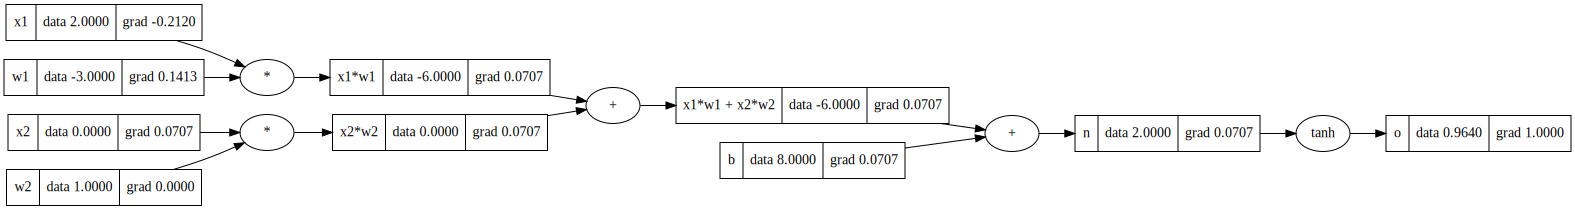

In [58]:
draw_dot(o)

In [59]:
# Neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(8.0,label='b')

x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label='n'

# tanh() formula
e = (2*n).exp(); e.label='e'
o = (e - 1) / (e + 1); o.label='o'
o.backward()

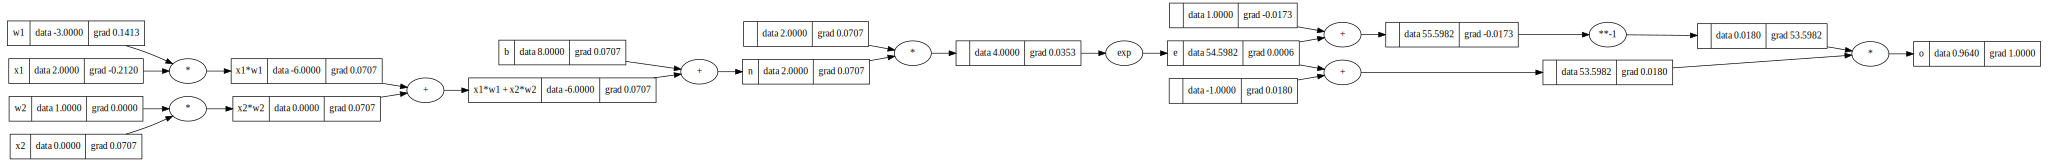

In [60]:
draw_dot(o)

In [61]:
o.grad = 1.0
n.grad = 1 - o.data**2  # do/dn = dtanh(n)/dn = 1 - (tanh(n))**2
# '+' is just a distributor of grads in backprop
b.grad = n.grad  # do/db = do/dn * dn/db = n.grad*1
x1w1x2w2.grad = n.grad
x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad
w2.grad = x2.data * x2w2.grad  # do/dw2 = do/dn * dn/dx1w1x2w2 * dx1w1x2w2/dx2w2 * dx2w2/dw2
x2.grad = w2.data * x2w2.grad
w1.grad = x1.data * x1w1.grad
x1.grad = w1.data * x1w1.grad

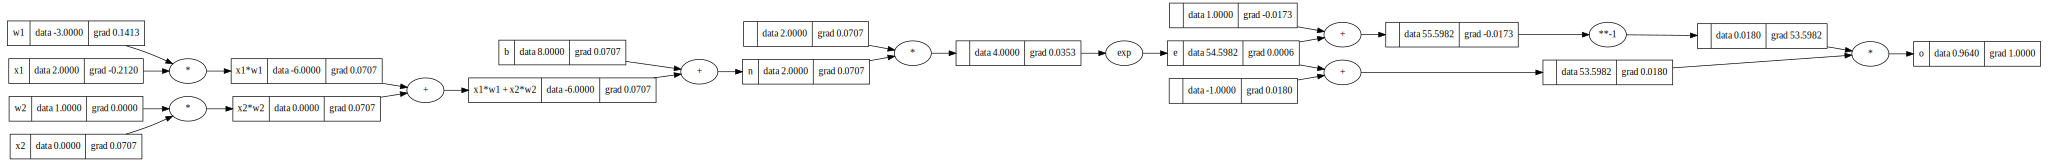

In [62]:
draw_dot(o)

In [63]:
o.grad = 1.0
o._backward()
n._backward()
b._backward()  # Leaf node empty function
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

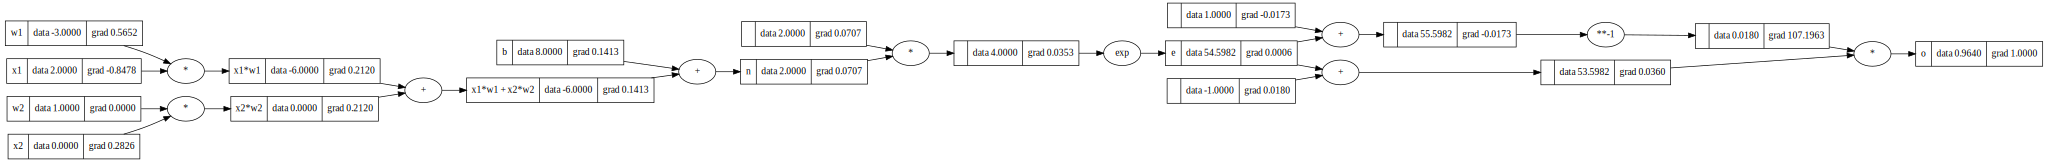

In [64]:
draw_dot(o)

In [65]:
import torch  # Efficient

In [66]:
# By default, requires_grad = False for leaf nodes; and float32 not 64
x1 = torch.tensor([2.0], dtype=torch.double, requires_grad = True)
x2 = torch.tensor([0.0], dtype=torch.double, requires_grad = True)
w1 = torch.tensor([-3.0], dtype=torch.double, requires_grad = True)
w2 = torch.tensor([1.0], dtype=torch.double, requires_grad = True)
b = torch.tensor([8.0], dtype=torch.double, requires_grad = True)

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())  # Strips away the tensor
o.backward()

print("------------")
print("x1:", x1.grad.item())
print("w1:", w1.grad.item())
print("x2:", x2.grad.item())
print("w2:", w2.grad.item())

0.9640275800758169
------------
x1: -0.2119524745594933
w1: 0.14130164970632886
x2: 0.07065082485316443
w2: 0.0


In [67]:
x1.grad

tensor([-0.2120], dtype=torch.float64)

In [68]:
import random

In [69]:
# Neural network

class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1, 1))

  def __call__(self, x):  # w*x + b
    # Activation; zip for efficiency
    act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:

  def __init__(self, nin, nout):
    # nout neurons with nin random weights for x[] each
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    # One neuron or middle layer list
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts  # sz = [nin, nouts[0], nouts[1], nouts[2]]
    # len(nouts) adjacent layers with i and i+1 neurons excluding input
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)  # Reassigning outputs to inputs for each layer
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


x = [2.0, 3.0]
n = Neuron(2) # nin
n(x)  # Function call
n = Layer(2, 3)
n(x)

[Value(data=0.9546058015051833),
 Value(data=-0.8503957308895767),
 Value(data=0.9505205979357598)]

In [70]:
# Neural net
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)
len(n.parameters())

41

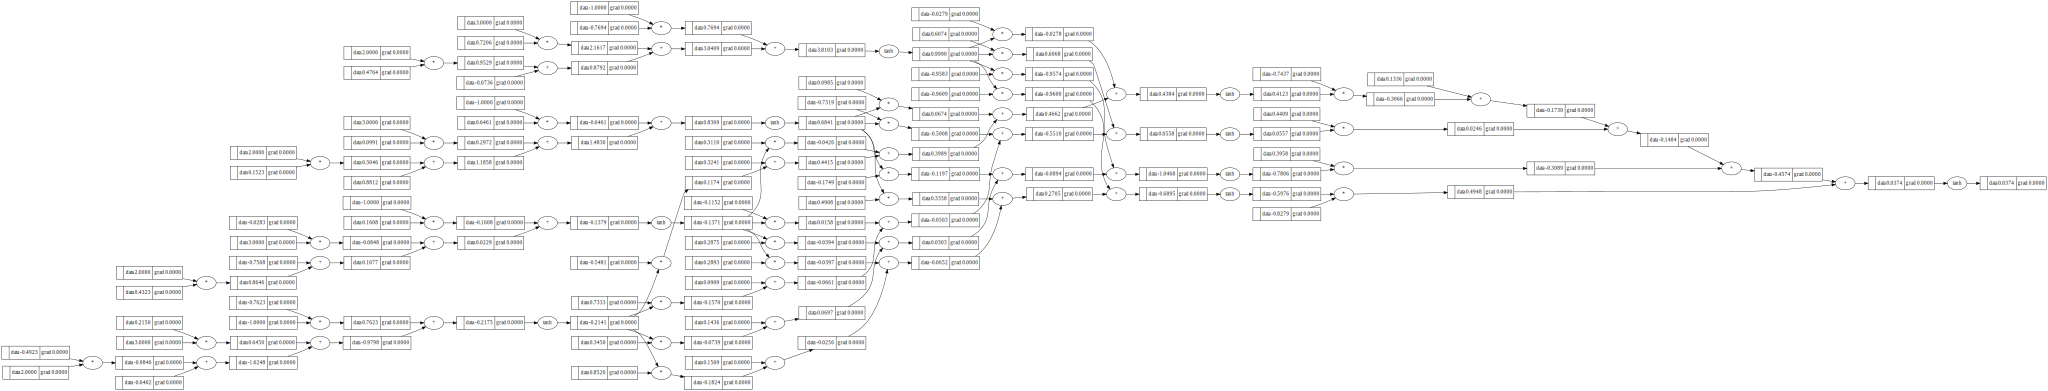

In [71]:
draw_dot(n(x))

In [72]:
# Corresponding inputs for desired targets
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0]
]

ys = [1.0, -1.0, -1.0, 1.0]

In [73]:
# Gradient descent
for k in range(20):

  ypred = [n(x) for x in xs]  # Forward pass
  loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])  # y ground truth

  for p in n.parameters():
    p.grad = 0.0

  loss.backward()  # For grad

  for p in n.parameters():  # Tuning the parameters
    p.data -=  0.01 * p.grad  # Against gradient to minimize loss

  print(k, loss.data)

0 1.7665817496990577
1 1.243338717541733
2 0.9486706853929243
3 0.7623357001245702
4 0.6307773700288745
5 0.5324439175073131
6 0.45667531593951993
7 0.39707238304344206
8 0.3493811394034458
9 0.3106389409580277
10 0.2787308373680739
11 0.25212038010661275
12 0.22967431127471438
13 0.21054475651547744
14 0.1940886622175559
15 0.17981195457585175
16 0.1673303442337464
17 0.15634146998635468
18 0.14660485491194394
19 0.13792730763703095


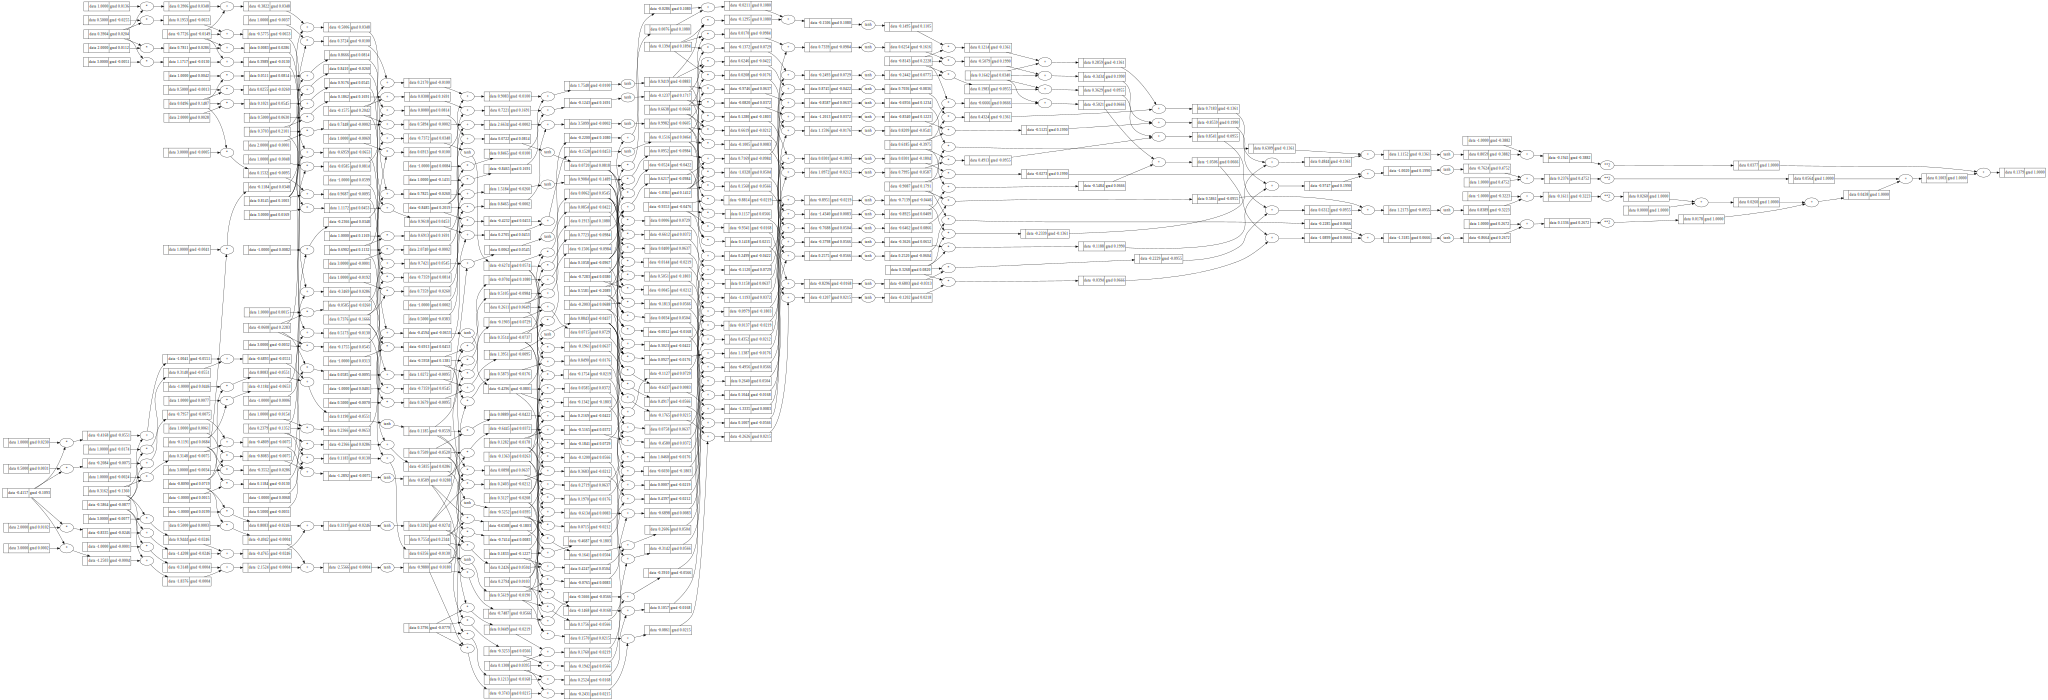

In [74]:
draw_dot(loss)